In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

<Figure size 1000x500 with 0 Axes>

In [47]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [48]:
#Basic data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [49]:
df.shape

(8807, 12)

In [50]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [51]:
df.describe

<bound method NDFrame.describe of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail M

In [52]:
#data cleaning
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [53]:
df['director'].fillna('Unknown', inplace=True)

In [54]:
df['cast'].fillna('Not Available', inplace=True)

In [55]:
df.dropna(subset=['country'], inplace=True)

In [56]:
#remove duplicate
df.drop_duplicates(inplace=True)

In [75]:
# feature engineering
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added']=df['date_added'].dt.year

### Statistical analysis

In [63]:
#Descriptive analysis
df['release_year'].mean()

2013.8855315947844

In [66]:
df['release_year'].median()

2017.0

In [67]:
df['release_year'].std()

8.957751693583164

In [83]:
df['release_year'].skew()

-3.335387005780296

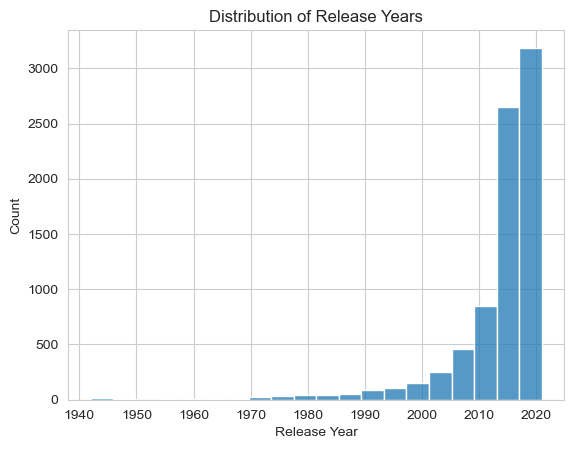

In [84]:
sns.histplot(df['release_year'], bins=20)

plt.title("Distribution of Release Years")

plt.xlabel("Release Year")

plt.ylabel("Count")

plt.show()

### EDA

In [76]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

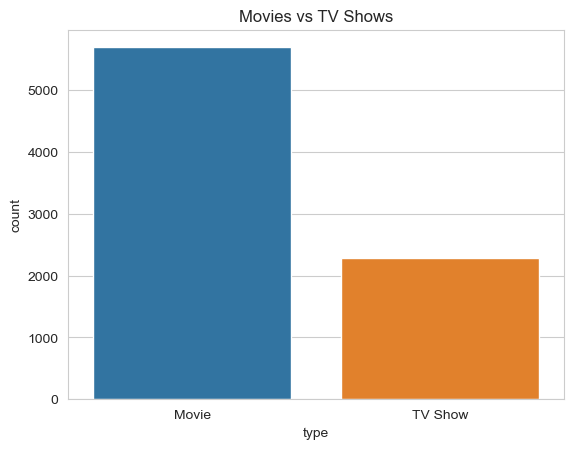

In [71]:
#compare content type
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

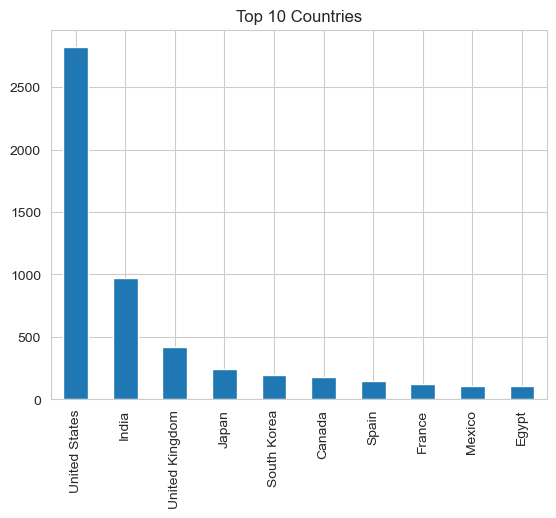

In [72]:
# identify major content producing countries
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")

plt.show()

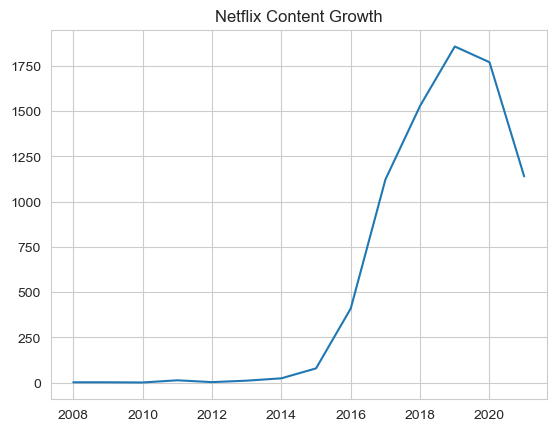

In [77]:
#content growth per year
df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Growth")

plt.show()

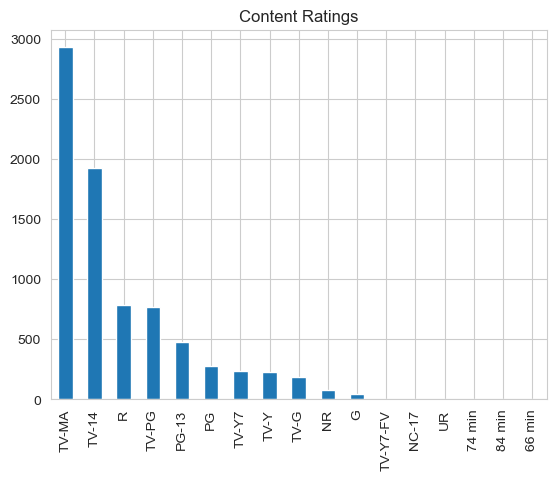

In [78]:
# content Rating analysis
df['rating'].value_counts().plot(kind='bar')
plt.title("Content Ratings")
plt.show()

In [79]:
# CORRELATION ANALYSIS
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

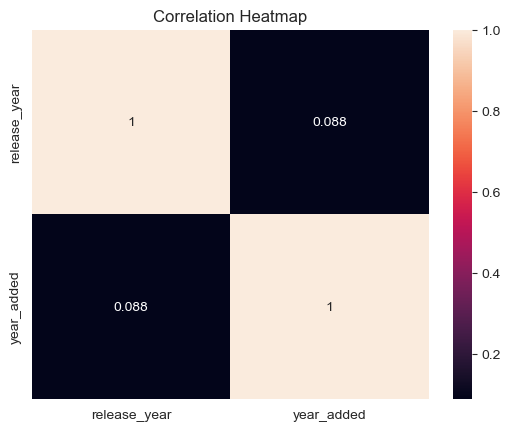

In [80]:
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [81]:
# hypothesis testing
from scipy.stats import ttest_ind
movies = df[df['type']=='Movie']['release_year']
tvshows = df[df['type']=='TV Show']['release_year']
t_stat, p_value = ttest_ind(movies, tvshows)
print(p_value)

1.6730329445352014e-60


In [ ]:
## INFERENCE

#### Mean Release Year
The average release year of Netflix content is approximately 2014, indicating that the platform mainly contains modern and recently produced content.

#### Median Release Year
The median release year is 2017, showing that most Netflix content belongs to recent years.

#### Standard Deviation
The release years are spread across multiple years, indicating a diverse content library.

#### Skewness
The release year distribution is highly negatively skewed because most content belongs to recent years while a smaller number of older titles extend the distribution toward earlier years.

## EDA Inferences

#### Movies vs TV Shows
Movies dominate the Netflix platform, indicating stronger focus on movie content.

#### Country Analysis
The United States contributes the highest number of Netflix titles.

#### Content Growth Trend
Netflix experienced rapid content expansion between 2014 and 2016 followed by continuous growth in later years.

#### Ratings Analysis
TV-MA and TV-14 are the most common ratings, showing strong focus on mature and teenage audiences.

# Correlation Analysis

Correlation analysis showed weak relationships among numerical variables, indicating limited linear dependency within the dataset.
A positive relationship exists between release year and year added, showing that recently produced content is generally added to Netflix in recent years.

## Hypothesis Testing

A T-Test was conducted to compare release years of Movies and TV Shows.

Inference:
There is a statistically significant difference between the release years of Movies and TV Shows, indicating that TV Shows on Netflix are generally more recent compared to Movies.
